# Bài toán: Phân loại Traffic Level

## Mục đích
- Phân loại mức độ giao thông của chuyến đi thành 3 nhãn: low, medium, high
- Tạo nhãn từ chỉ số `traffic_index = trip_duration / trip_distance`
- Không dùng `trip_duration` làm feature để tránh data leakage
- So sánh chỉ 3 mô hình ML và chọn mô hình tốt nhất

## Ghi chú
- Chưa dùng `location_cluster` và `behavior_cluster` vì đây là các đầu ra của bài toán khác
- Notebook này sẽ chỉ dùng các đặc trưng có sẵn từ lộ trình và khoảng cách

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2. Load và làm sạch dữ liệu

In [5]:
# Load raw taxi data
df = pd.read_csv('../data/raw/yellow_tripdata_2016-03.csv', nrows=100000)

# Convert datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Create trip_duration only for label generation
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

# Basic cleaning
df = df[(df['pickup_longitude'] != 0) & (df['pickup_latitude'] != 0)]
df = df[(df['dropoff_longitude'] != 0) & (df['dropoff_latitude'] != 0)]
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 7200)]
df = df.dropna().copy()

print(f'✅ Data loaded: {df.shape}')
print(df[['trip_distance', 'trip_duration']].describe())

✅ Data loaded: (98403, 20)
       trip_distance  trip_duration
count   98403.000000   98403.000000
mean        3.045078     859.503389
std         3.760785     647.919182
min         0.010000       1.000000
25%         1.000000     408.000000
50%         1.680000     690.000000
75%         3.200000    1119.000000
max        47.000000    7013.000000


## 3. Tạo nhãn traffic_level

In [7]:
# traffic_index phản ánh mức độ ùn tắc: thời gian trên mỗi dặm
df['traffic_index'] = df['trip_duration'] / (df['trip_distance'] + 1e-6)

low = df['traffic_index'].quantile(0.33)
high = df['traffic_index'].quantile(0.66)

def label_traffic(x):
    if x < low:
        return 0  # low traffic
    elif x < high:
        return 1  # medium traffic
    else:
        return 2  # high traffic

df['traffic_level'] = df['traffic_index'].apply(label_traffic)

print('✅ traffic_level created')
print(f'Low threshold  : {low:.2f}')
print(f'High threshold : {high:.2f}')
print('\nTraffic level distribution:')
print(df['traffic_level'].value_counts().sort_index())
print(f'\nClass ratio:')
print(df['traffic_level'].value_counts(normalize=True).sort_index().apply(lambda x: f'{x:.2%}'))

✅ traffic_level created
Low threshold  : 279.13
High threshold : 447.83

Traffic level distribution:
traffic_level
0    32473
1    32472
2    33458
Name: count, dtype: int64

Class ratio:
traffic_level
0    33.00%
1    33.00%
2    34.00%
Name: proportion, dtype: object


## 4. Phân tích nhanh nhãn

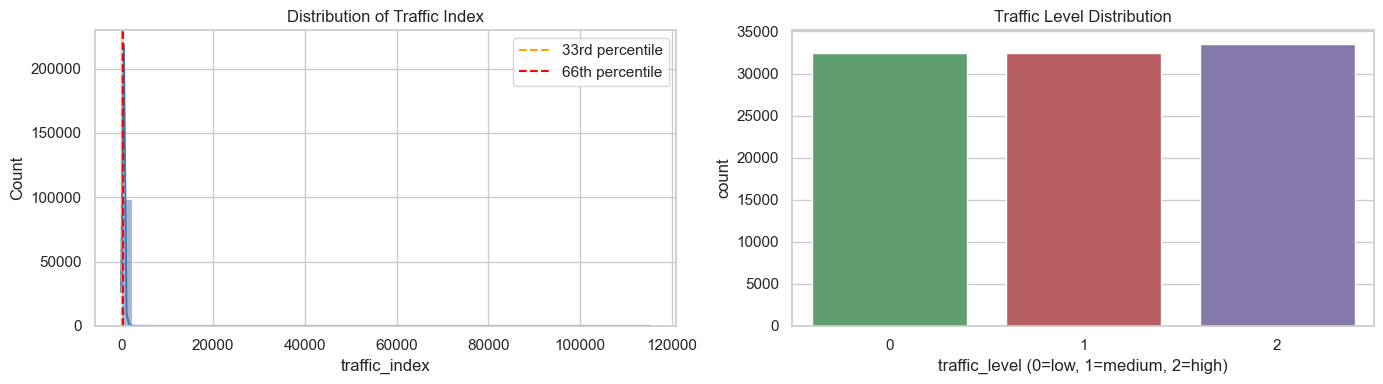

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['traffic_index'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].axvline(low, color='orange', linestyle='--', label='33rd percentile')
axes[0].axvline(high, color='red', linestyle='--', label='66th percentile')
axes[0].set_title('Distribution of Traffic Index')
axes[0].legend()

sns.countplot(x='traffic_level', data=df, ax=axes[1], palette=['#55A868', '#C44E52', '#8172B2'])
axes[1].set_title('Traffic Level Distribution')
axes[1].set_xlabel('traffic_level (0=low, 1=medium, 2=high)')

plt.tight_layout()
plt.show()

## 5. Chọn features

Chưa dùng `location_cluster` và `behavior_cluster` ở giai đoạn này.
Không dùng `trip_duration` để tránh leakage.

In [9]:
feature_cols = [
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'trip_distance'
]

X = df[feature_cols].copy()
y = df['traffic_level'].copy()

print(f'Features used: {feature_cols}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Features used: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_distance']
X shape: (98403, 5)
y shape: (98403,)


## 6. Train/Test Split và scaling

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f"Train class ratio:\n{y_train.value_counts(normalize=True).sort_index()}")
print(f"Test class ratio:\n{y_test.value_counts(normalize=True).sort_index()}")

Train: (78722, 5) | Test: (19681, 5)
Train class ratio:
traffic_level
0    0.329997
1    0.329997
2    0.340007
Name: proportion, dtype: float64
Test class ratio:
traffic_level
0    0.330014
1    0.329963
2    0.340023
Name: proportion, dtype: float64


## 7. Chọn 3 mô hình và lý do

1. **Logistic Regression**: baseline tuyến tính, dễ giải thích, phù hợp để kiểm tra xem các đặc trưng vị trí có tách lớp được không.
2. **Random Forest**: bắt được quan hệ phi tuyến giữa tọa độ và mức độ traffic, ít nhạy với scaling.
3. **XGBoost**: mạnh trên dữ liệu bảng, thường cho kết quả tốt khi có nhiều tương tác phi tuyến và biên phức tạp.

In [13]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=500, multi_class='multinomial'), True),
    'Random Forest': (RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), False),
    'XGBoost': (XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ), False)
}

print(f'✅ {len(models)} models ready')

✅ 3 models ready


## 8. Training và đánh giá

In [14]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, needs_scaling) in models.items():
    print(f'Training {name}...')
    X_tr = X_train_sc if needs_scaling else X_train
    X_te = X_test_sc if needs_scaling else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    results[name] = {
        'model': model,
        'scaled': needs_scaling,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'y_pred': y_pred
    }

    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    results[name]['cv_f1_macro_mean'] = cv_scores.mean()
    results[name]['cv_f1_macro_std'] = cv_scores.std()

    print(f"  Accuracy: {results[name]['accuracy']:.4f}")
    print(f"  Macro F1 : {results[name]['f1_macro']:.4f}")
    print(f"  CV F1    : {results[name]['cv_f1_macro_mean']:.4f} ± {results[name]['cv_f1_macro_std']:.4f}")

print('✅ All models trained')

Training Logistic Regression...
  Accuracy: 0.5308
  Macro F1 : 0.5231
  CV F1    : 0.5281 ± 0.0022
Training Random Forest...
  Accuracy: 0.6260
  Macro F1 : 0.6271
  CV F1    : 0.6286 ± 0.0020
Training XGBoost...
  Accuracy: 0.6362
  Macro F1 : 0.6370
  CV F1    : 0.6386 ± 0.0024
✅ All models trained


## 9. So sánh kết quả và chọn mô hình tốt nhất

In [15]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision Macro': [results[m]['precision_macro'] for m in results],
    'Recall Macro': [results[m]['recall_macro'] for m in results],
    'F1 Macro': [results[m]['f1_macro'] for m in results],
    'CV F1 Macro': [results[m]['cv_f1_macro_mean'] for m in results],
})

comparison_df = comparison_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print('📊 Model comparison')
print(comparison_df.to_string(index=False))
print(f"\n🏆 Best model: {best_model_name}")

📊 Model comparison
              Model  Accuracy  Precision Macro  Recall Macro  F1 Macro  CV F1 Macro
            XGBoost  0.636197         0.649425      0.635141  0.636998     0.638603
      Random Forest  0.625984         0.643802      0.624858  0.627124     0.628594
Logistic Regression  0.530817         0.547542      0.528939  0.523090     0.528053

🏆 Best model: XGBoost


## 10. Confusion matrix và báo cáo chi tiết

              precision    recall  f1-score   support

         low       0.80      0.63      0.71      6495
      medium       0.54      0.53      0.53      6494
        high       0.61      0.74      0.67      6692

    accuracy                           0.64     19681
   macro avg       0.65      0.64      0.64     19681
weighted avg       0.65      0.64      0.64     19681



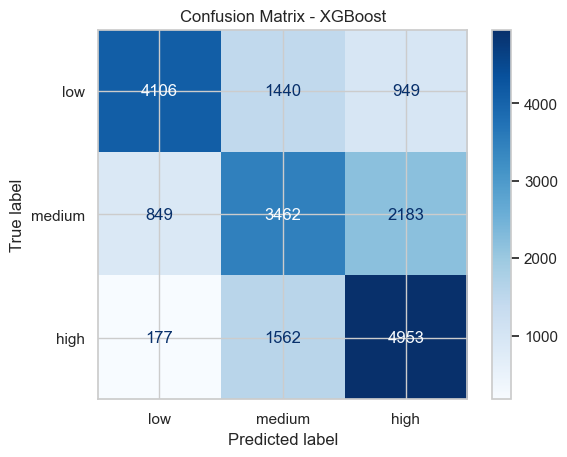

In [16]:
best_needs_scaling = results[best_model_name]['scaled']
X_te_best = X_test_sc if best_needs_scaling else X_test
y_pred_best = best_model.predict(X_te_best)

print(classification_report(y_test, y_pred_best, target_names=['low', 'medium', 'high'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 11. Dự đoán traffic_level cho toàn bộ dataset và lưu kết quả

In [17]:
# Predict on full cleaned dataset
X_full = df[feature_cols].copy()
if results[best_model_name]['scaled']:
    X_full_input = scaler.transform(X_full)
else:
    X_full_input = X_full

df['predicted_traffic_level'] = best_model.predict(X_full_input)

print('✅ Full dataset predicted')
print(df[['traffic_level', 'predicted_traffic_level']].head())

output_path = '../data/raw/taxi_with_traffic_level.csv'
save_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'trip_distance', 'trip_duration',
    'traffic_index', 'traffic_level', 'predicted_traffic_level'
]
save_cols = [c for c in save_cols if c in df.columns]
df[save_cols].to_csv(output_path, index=False)
print(f'✅ Saved output to: {output_path}')

✅ Full dataset predicted
   traffic_level  predicted_traffic_level
0              0                        2
1              0                        1
2              0                        0
7              0                        0
8              1                        2
✅ Saved output to: ../data/raw/taxi_with_traffic_level.csv
